In [10]:
!pip install opencv-python

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import cv2
import random

**CIFAR-10 (For Parts 1 – 3)**

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


**Part 1: The Dimensionality Crisis (FFN)**

In [ ]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [ ]:
ffn = FFN()
optimizer = optim.Adam(ffn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = ffn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print("FFN Epoch:", epoch+1)

FFN Epoch: 1
FFN Epoch: 2
FFN Epoch: 3
FFN Epoch: 4
FFN Epoch: 5


In [ ]:
def shift_image(img):
    return torch.roll(img, shifts=4, dims=2)

**Part 2: The CNN Baseline**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU()
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
cnn = CNN()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

for epoch in range(10):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print("CNN Epoch:", epoch+1)

CNN Epoch: 1
CNN Epoch: 2
CNN Epoch: 3
CNN Epoch: 4
CNN Epoch: 5
CNN Epoch: 6
CNN Epoch: 7
CNN Epoch: 8
CNN Epoch: 9
CNN Epoch: 10


In [ ]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(512, 10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 251MB/s]


**Part 3: MobileNet & Efficiency**

In [18]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.depthwise = nn.Conv2d(in_c, in_c, 3, padding=1, groups=in_c)
        self.pointwise = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))

In [19]:
class MobileCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            DepthwiseSeparableConv(3, 32), nn.ReLU(),
            DepthwiseSeparableConv(32, 64), nn.ReLU(),
            DepthwiseSeparableConv(64, 128), nn.ReLU()
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

**BCCD Dataset**

In [11]:
!git clone https://github.com/Shenggan/BCCD_Dataset.git

fatal: destination path 'BCCD_Dataset' already exists and is not an empty directory.


In [12]:
img_dir = "BCCD_Dataset/BCCD/JPEGImages"
ann_dir = "BCCD_Dataset/BCCD/Annotations"

all_images = os.listdir(img_dir)
random.shuffle(all_images)

split = int(0.8 * len(all_images))
train_images = all_images[:split]
test_images = all_images[split:]

In [13]:
class BCCD_Dataset(Dataset):
    def __init__(self, img_dir, ann_dir, image_list, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.images = image_list
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        ann_path = os.path.join(self.ann_dir, img_name.split('.')[0] + '.xml')

        img = cv2.imread(img_path)
        h, w, _ = img.shape

        tree = ET.parse(ann_path)
        root = tree.getroot()

        obj = root.find('object')
        bbox = obj.find('bndbox')

        xmin = int(bbox.find('xmin').text) / w
        ymin = int(bbox.find('ymin').text) / h
        xmax = int(bbox.find('xmax').text) / w
        ymax = int(bbox.find('ymax').text) / h

        box = torch.tensor([xmin, ymin, xmax-xmin, ymax-ymin], dtype=torch.float32)

        label = torch.tensor(1)

        if self.transform:
            img = self.transform(img)

        return img, label, box

In [14]:
transform_det = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

train_dataset = BCCD_Dataset(img_dir, ann_dir, train_images, transform_det)
test_dataset = BCCD_Dataset(img_dir, ann_dir, test_images, transform_det)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [15]:
class DetectionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = MobileCNN().conv
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 64)

        self.class_head = nn.Linear(64, 1)
        self.box_head = nn.Linear(64, 4)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        cls = self.class_head(x)
        box = torch.sigmoid(self.box_head(x))
        return cls, box

In [16]:
def loss_fn(cls_pred, cls_true, box_pred, box_true):
    ce = nn.BCEWithLogitsLoss()(cls_pred.squeeze(), cls_true.float())
    mse = nn.MSELoss()(box_pred, box_true)
    return ce + mse

In [20]:
model = DetectionModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    for imgs, labels, boxes in train_loader:
        optimizer.zero_grad()

        cls_pred, box_pred = model(imgs)

        loss = loss_fn(cls_pred, labels, box_pred, boxes)

        loss.backward()
        optimizer.step()

    print("Detection Epoch:", epoch+1)

Detection Epoch: 1
Detection Epoch: 2
Detection Epoch: 3
Detection Epoch: 4
Detection Epoch: 5


In [2]:
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[0]+box1[2], box2[0]+box2[2])
    y2 = min(box1[1]+box1[3], box2[1]+box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)
    union = box1[2]*box1[3] + box2[2]*box2[3] - inter

    return inter / union

In [22]:
def draw_boxes(img, pred_box, gt_box):
    img = img.copy()
    h, w, _ = img.shape

    px = int(pred_box[0] * w)
    py = int(pred_box[1] * h)
    pw = int(pred_box[2] * w)
    ph = int(pred_box[3] * h)

    gx = int(gt_box[0] * w)
    gy = int(gt_box[1] * h)
    gw = int(gt_box[2] * w)
    gh = int(gt_box[3] * h)

    cv2.rectangle(img, (px, py), (px+pw, py+ph), (0,0,255), 2)
    cv2.rectangle(img, (gx, gy), (gx+gw, gy+gh), (0,255,0), 2)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Red: Predicted | Green: Ground Truth")
    plt.axis('off')
    plt.show()

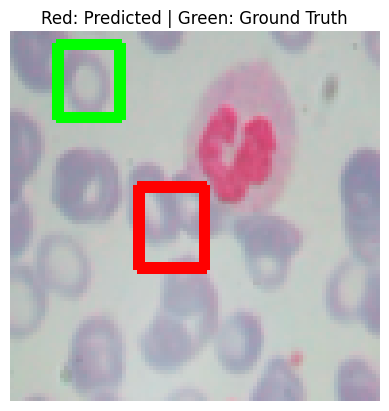

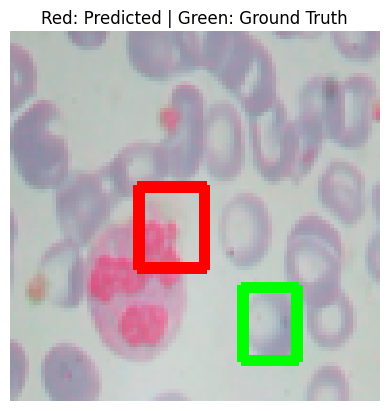

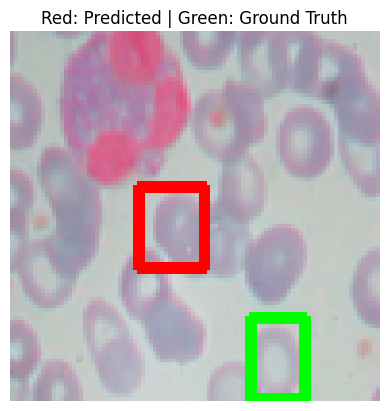

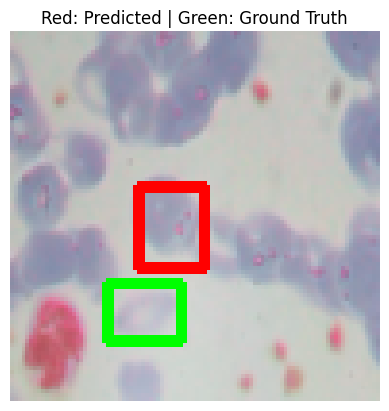

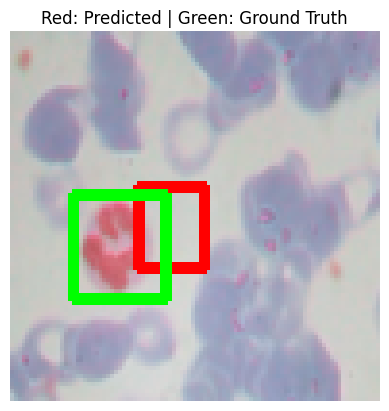

In [23]:
model.eval()

count = 0

for imgs, labels, boxes in test_loader:
    cls_pred, box_pred = model(imgs)

    for i in range(len(imgs)):
        # Convert tensor → numpy image
        img = imgs[i].permute(1, 2, 0).numpy()
        img = img * 255
        img = img.astype(np.uint8)

        # Convert RGB → BGR for OpenCV
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        draw_boxes(img, box_pred[i].detach().numpy(), boxes[i].numpy())

        count += 1
        if count == 5:
            break

    if count == 5:
        break